# **K-Means Clustering**
---
## **Apa itu K-Mean clustering?**

K-Means Clustering adalah algoritma unsupervised learning (data tanpa label) yang memartisi sekumpulan data ke dalam **K** kluster yang tidak saling tumpang tindih. Agar data dalam satu kluster sehomogen mungkin dan seheterogen mungkin dengan data di kluster lain, yaitu memiliki karakteristik yang semirip mungkin dengan data dalam satu kluster dan setidakmirip mungkin dengan data di kluster lain.

"K-Means" berasal dari dua hal:

- K = jumlah kluster yang ingin dibuat (ditentukan oleh user).

- Means = rata-rata, setiap kluster direpresentasikan oleh centroid, yaitu rata-rata posisi titik-titik dalam kluster tersebut.

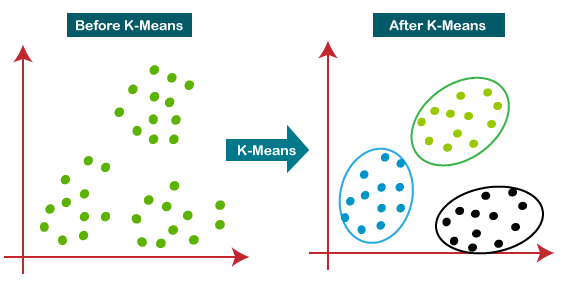

---

## **Cara kerja algoritma K-Means**
1. Tentukan Jumlah kluster **K** (misalkan K=3)
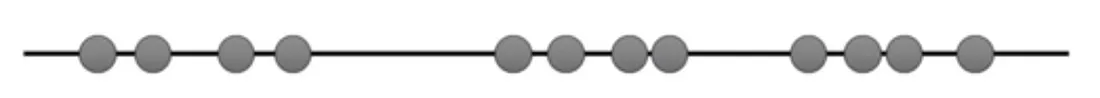

2. Tentukan K centroid awal secara acak

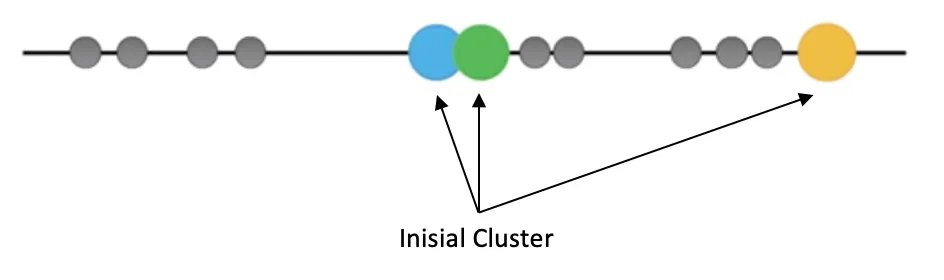

3. Hitung jarak dari setiap titik data ke semua centroid

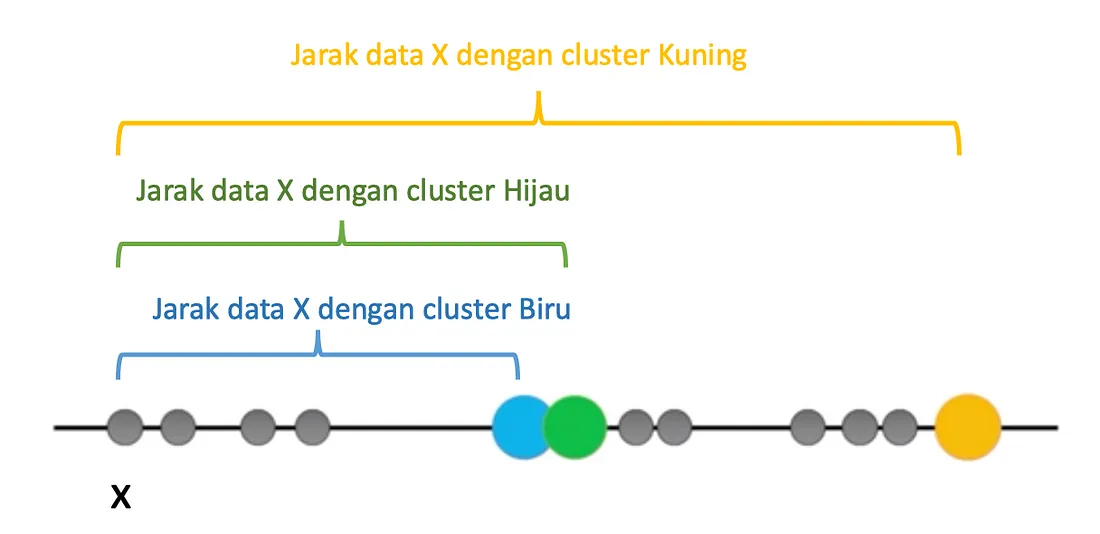

4. kelompokkan data berdasarkan centroid terdekat

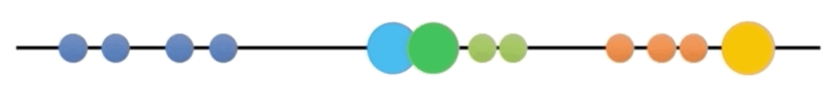

5. Hitung ulang centroid dari rata-rata anggota kluster

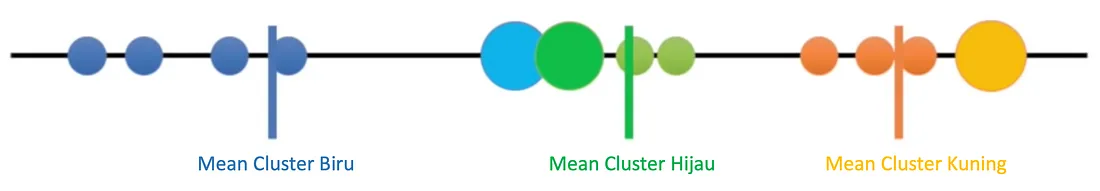

6. Ulangi langkah 3-5 hingga tidak ada lagi perubahan anggota kluster, atau hingga centroid sudah tidak berubah (konvergen).

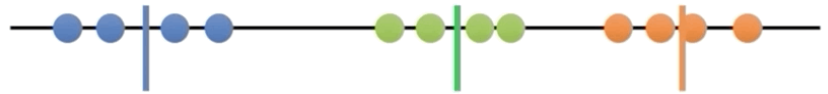

---
### **Contoh K-Means Clustering**

Data:

| Titik | X | Y |
| ----- | - | - |
| A     | 1 | 1 |
| B     | 1 | 2 |
| C     | 2 | 1 |
| D     | 8 | 8 |
| E     | 9 | 8 |
| F     | 8 | 9 |


1. tentukan centroid (K=2)

  Pilih 2 titik sebagai centroid awal (misalnya ambil titik A dan D):

* Centroid 1 (C1): A = (1, 1)
* Centroid 2 (C2): D = (8, 8)


2. Hitung jarak tiap titik ke centroid

  Gunakan **jarak Euclidean**:

$$
\text{Jarak} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}
$$


| Titik | ke C1 (1,1)                | ke C2 (8,8)               | Kluster |
| ----- | -------------------------- | ------------------------- | ------- |
| A     | √((1−1)² + (1−1)²) = 0.00  | √((1−8)² + (1−8)²) = 9.90 |    C1   |
| B     | √((1−1)² + (2−1)²) = 1.00  | √((1−8)² + (2−8)²) = 9.22 |    C1   |
| C     | √((2−1)² + (1−1)²) = 1.00  | √((2−8)² + (1−8)²) = 9.22 |    C1   |
| D     | √((8−1)² + (8−1)²) = 9.90  | √((8−8)² + (8−8)²) = 0.00 |    C2   |
| E     | √((9−1)² + (8−1)²) = 10.63 | √((9−8)² + (8−8)²) = 1.00 |    C2   |
| F     | √((8−1)² + (9−1)²) = 10.63 | √((8−8)² + (9−8)²) = 1.00 |    C2   |




4. Update centroid

Hitung rata-rata X dan Y untuk setiap kluster:

* Centroid baru Kluster 1:

  $$
  C1 = \left( \frac{1+1+2}{3}, \frac{1+2+1}{3} \right) = (1.33, 1.33)
  $$
* Centroid baru Kluster 2:

  $$
  C2 = \left( \frac{8+9+8}{3}, \frac{8+8+9}{3} \right) = (8.33, 8.33)
  $$


**Hasil akhir:**

* Kluster 1: A, B, C
* Kluster 2: D, E, F

  (Sudah stabil, tidak berubah)

---



## **Evaluasi hasil klustering**
### 1. **SSE** (sum of squared errors) / inertia
  
  $$
  SSE = \sum_{i=1}^{n} \| xᵢ - Ucᵢ \|²
  $$

  Mengukur total jarak kuadrat antara tiap titik dan centroid-nya.

keterangan:

- $x_i$ : Dimana titik data ke-**i**
- $Uc_i$ : Centroid dari cluster tempat $x_i$ berada


 Semakin kecil nilai inertia, semakin baik.



| **Nilai Inertia**              | **Arti**                                                                                                |
| ------------------------------ | ------------------------------------------------------------------------------------------------------- |
| **Sangat kecil** (mendekati 0) | Klaster sangat kompak dan semua titik dekat dengan centroidnya → **sangat baik**                        |
| **Kecil hingga sedang**        | Klaster cukup baik dan dapat diterima dalam banyak kasus                                                |
| **Besar**                      | Klaster tidak rapat, mungkin distribusi datanya tidak cocok dengan K-Means atau nilai *k* terlalu kecil |

---

### 2.  **Silhouette Analysis**

**Silhouette Analysis** mengukur seberapa baik suatu titik data sesuai dengan klaster tempat ia dikelompokkan, dibandingkan dengan klaster lain.

Untuk setiap titik $i$, **silhouette score** $s(i)$ dihitung sebagai:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}
$$

#### **Keterangan:**

* $a(i)$: Rata-rata jarak titik $i$ ke semua titik lain dalam **klaster yang sama**
* $b(i)$: Rata-rata jarak titik $i$ ke semua titik dalam **klaster terdekat (tetangga)**

---


## **Implementasi K-Means pada dataset iris**

### **1. Persiapan data**

Dataset Iris memiliki 150 sampel bunga Iris dari tiga spesies: Setosa, Versicolor, dan Virginica, dengan empat fitur kontinu: panjang dan lebar sepal, serta panjang dan lebar petal. Dalam kasus ini, kita akan menggunakan data Iris tanpa label target (spesies) untuk menguji algoritma K-Means (unsupervised learning).

**Menghapus Kolom Label (Target)**

menghapus kolom target species karena K-Means adalah algoritma unsupervised yang tidak membutuhkan label.

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

# Memuat dataset Iris
iris = load_iris()
X = iris.data  # Matriks fitur
y = iris.target  # Label asli (tidak digunakan untuk clustering)


### **2. Visualisasi Data**

Sebelum melakukan clustering, kita akan visualisasikan data untuk melihat distribusinya. Kita akan menggunakan PCA (Principal Component Analysis) untuk mereduksi dimensi data menjadi dua dimensi sehingga dapat divisualisasikan dengan mudah.

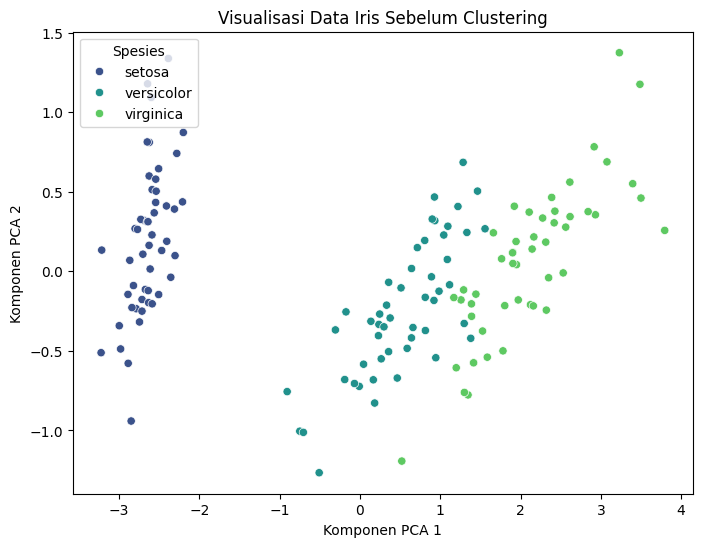

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Menggunakan PCA untuk mereduksi dimensi ke 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualisasi data sebelum clustering menggunakan PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target_names[y], palette='viridis')
plt.title("Visualisasi Data Iris Sebelum Clustering")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend(title="Spesies", loc="upper left")
plt.show()


### **3. Proses clustering K-Means**

Melakukan clustering menggunakan K-Means dengan berbagai jumlah klaster (k=2, 3, 4) dan mengevaluasi hasilnya menggunakan SSE (Sum of Squared Errors) dan Silhouette Score.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Menjalankan KMeans dengan k=2, 3, dan 4
sse = []
silhouette_scores = []
labels_dict = {}

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    kmeans_labels = kmeans.fit_predict(X)
    labels_dict[k] = kmeans_labels
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans_labels))

    # Menampilkan centroid untuk setiap klaster
    print(f"Klaster {k} Centroids:\n", kmeans.cluster_centers_[:2])  # hanya dua dimensi pertama untuk visualisasi


Klaster 2 Centroids:
 [[6.30103093 2.88659794 4.95876289 1.69587629]
 [5.00566038 3.36981132 1.56037736 0.29056604]]
Klaster 3 Centroids:
 [[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]]
Klaster 4 Centroids:
 [[6.2525 2.855  4.815  1.625 ]
 [5.006  3.428  1.462  0.246 ]]


Evaluasi Model:

- SSE (Inertia) mengukur total jarak antara titik data dan pusat klaster (semakin kecil SSE, semakin baik klaster tersebut).

- Silhouette Score mengukur seberapa baik data berada dalam klasternya, dengan nilai +1 menunjukkan klaster yang terpisah dengan baik dan nilai mendekati 0 menunjukkan klaster yang saling tumpang tindih.

### **4. Visualisasi Hasil Clustering**

memvisualisasikan hasil clustering untuk setiap nilai k (k=2, k=3, k=4), menggunakan PCA untuk mereduksi dimensi.

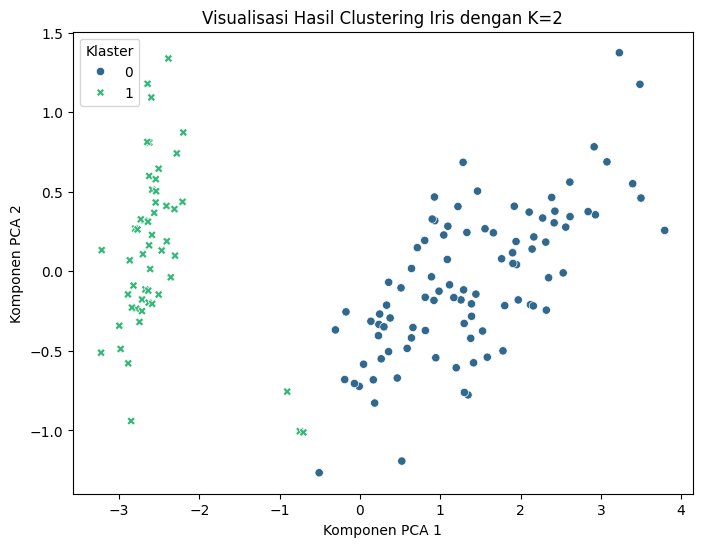

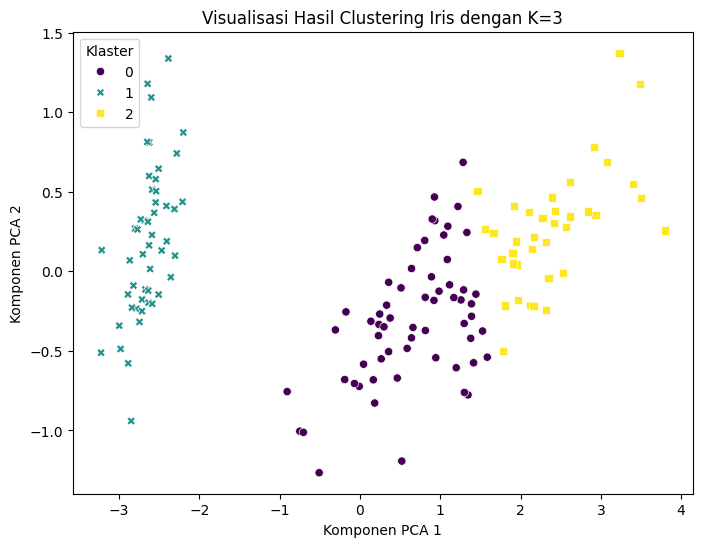

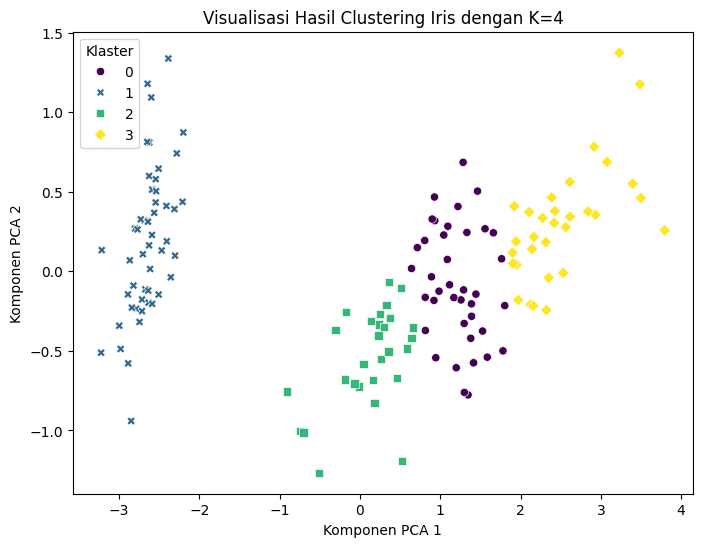

In [5]:
# Visualisasi hasil clustering (k=2) menggunakan PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dict[2], palette='viridis', style=labels_dict[2], markers=["o", "X"])
plt.title("Visualisasi Hasil Clustering Iris dengan K=2")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend(title="Klaster", loc="upper left")
plt.show()
# Visualisasi hasil clustering (k=3) menggunakan PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dict[3], palette='viridis', style=labels_dict[3], markers=["o", "X", "s"])
plt.title("Visualisasi Hasil Clustering Iris dengan K=3")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend(title="Klaster", loc="upper left")
plt.show()
# Visualisasi hasil clustering (k=4) menggunakan PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dict[4], palette='viridis', style=labels_dict[4], markers=["o", "X", "s", "D"])
plt.title("Visualisasi Hasil Clustering Iris dengan K=4")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend(title="Klaster", loc="upper left")
plt.show()


### **5. Evaluasi Model: SSE dan Silhouette Score**

menghitung SSE dan Silhouette Score untuk setiap nilai k untuk membantu kita menentukan klaster yang optimal.

In [6]:
# Menampilkan hasil evaluasi untuk setiap k
for k in [2, 3, 4]:
    print(f"Untuk k={k}:")
    print(f"  SSE (Inertia): {sse[k-2]}")
    print(f"  Silhouette Score: {silhouette_scores[k-2]}")


Untuk k=2:
  SSE (Inertia): 152.34795176035797
  Silhouette Score: 0.6810461692117462
Untuk k=3:
  SSE (Inertia): 78.851441426146
  Silhouette Score: 0.5528190123564095
Untuk k=4:
  SSE (Inertia): 57.22847321428572
  Silhouette Score: 0.49805050499728737


### **6. Visualisasi dengan elbow curve**

<ipython-input-13-7f497567f6bc>:26: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  num = np.abs(np.cross(point2 - point1, point1 - point))


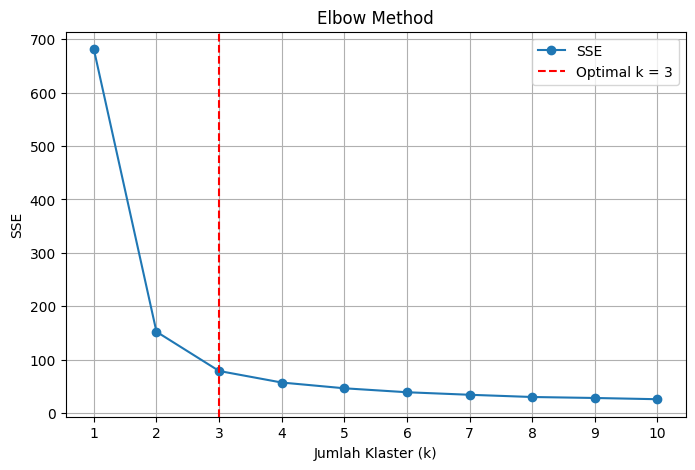

In [13]:
import numpy as np
k_range = range(1, 11)
sse = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Deteksi titik elbow secara otomatis
# Gunakan metode garis lurus dari titik pertama ke terakhir, cari titik dengan jarak maksimum ke garis
from scipy.spatial.distance import euclidean

x = np.array(list(k_range))
y = np.array(sse)

# Titik awal dan akhir
point1 = np.array([x[0], y[0]])
point2 = np.array([x[-1], y[-1]])

# Hitung jarak tegak lurus dari tiap titik ke garis lurus (point1 -> point2)
distances = []
for i in range(len(x)):
    point = np.array([x[i], y[i]])
    # Rumus jarak titik ke garis (via cross product)
    num = np.abs(np.cross(point2 - point1, point1 - point))
    denom = np.linalg.norm(point2 - point1)
    distance = num / denom
    distances.append(distance)

# Dapatkan index k dengan jarak maksimum
optimal_idx = np.argmax(distances)
optimal_k = x[optimal_idx]

# Visualisasi Elbow + titik optimal
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', label='SSE')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()